<a href="https://colab.research.google.com/github/vuhamodala/Float-Chat-for-Indian-ocean-Data/blob/main/Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("arabian_sea_8features.csv")

In [3]:
df = df.dropna()

In [4]:
df['temp_lag1'] = df['temp_mean'].shift(1)
df['temp_lag7'] = df['temp_mean'].shift(7)

df['sal_lag1'] = df['sal_mean'].shift(1)
df['sal_lag7'] = df['sal_mean'].shift(7)

In [5]:
df['temp_roll7'] = df['temp_mean'].rolling(7).mean()
df['sal_roll7'] = df['sal_mean'].rolling(7).mean()

In [6]:
df = df.dropna()

In [7]:
features = [
    'temp_std', 'sal_mean', 'sal_std',
    'day_of_year', 'month',
    'temp_trend', 'sal_trend',
    'temp_lag1', 'temp_lag7',
    'sal_lag1', 'sal_lag7',
    'temp_roll7', 'sal_roll7'
]

target = 'temp_mean'

In [8]:
df = df.sort_values("time")

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:]

In [9]:
X_train_xgb = train_df[features]
y_train_xgb = train_df[target]

X_test_xgb = test_df[features]
y_test_xgb = test_df[target]

In [10]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
xgb_test_pred = xgb_model.predict(X_test_xgb)
xgb_test_true = y_test_xgb.values

In [12]:
lstm_features = [
    'temp_mean', 'temp_std', 'sal_mean', 'sal_std',
    'day_of_year', 'month',
    'temp_trend', 'sal_trend'
]

data_lstm = df[lstm_features].values

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_lstm)


In [14]:
import numpy as np

def create_sequences(data, window=40):
    X, y = [], []

    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0])  # temp_mean

    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(data_scaled, window=40)

In [15]:
split_lstm = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_lstm]
X_test_lstm  = X_lstm[split_lstm:]

y_train_lstm = y_lstm[:split_lstm]
y_test_lstm  = y_lstm[split_lstm:]

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(40, 8)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

model.fit(
    X_train_lstm, y_train_lstm,
    epochs=40,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stop]
)

Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0250 - val_loss: 0.0044
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0029 - val_loss: 0.0033
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 12/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0

In [18]:
lstm_test_pred = model.predict(X_test_lstm).flatten()
lstm_test_true = y_test_lstm

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [19]:
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

lstm_test_pred = lstm_test_pred * (temp_max - temp_min) + temp_min
lstm_test_true = lstm_test_true * (temp_max - temp_min) + temp_min

In [20]:
xgb_test_pred = xgb_test_pred[40:]
xgb_test_true = xgb_test_true[40:]

In [22]:
print(len(lstm_test_pred))
print(len(xgb_test_pred))


355
323


In [23]:
xgb_test_pred = xgb_test_pred[-len(lstm_test_pred):]
xgb_test_true = xgb_test_true[-len(lstm_test_pred):]

In [32]:
min_len = min(len(lstm_test_pred), len(xgb_test_pred))

lstm_test_pred = lstm_test_pred[-min_len:]
xgb_test_pred  = xgb_test_pred[-min_len:]
lstm_test_true = lstm_test_true[-min_len:]

In [28]:
lstm_train_pred = model.predict(X_train_lstm).flatten()
lstm_train_true = y_train_lstm

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [29]:
lstm_train_pred = lstm_train_pred * (temp_max - temp_min) + temp_min
lstm_train_true = lstm_train_true * (temp_max - temp_min) + temp_min

In [30]:
xgb_train_pred = xgb_model.predict(X_train_xgb)
xgb_train_true = y_train_xgb.values

In [31]:
min_len_train = min(len(lstm_train_pred), len(xgb_train_pred))

lstm_train_pred = lstm_train_pred[-min_len_train:]
xgb_train_pred  = xgb_train_pred[-min_len_train:]
lstm_train_true = lstm_train_true[-min_len_train:]

In [33]:
ensemble_train_pred = (0.6 * lstm_train_pred) + (0.4 * xgb_train_pred)
y_train_final = lstm_train_true

In [34]:
min_len_test = min(len(lstm_test_pred), len(xgb_test_pred))

lstm_test_pred = lstm_test_pred[-min_len_test:]
xgb_test_pred  = xgb_test_pred[-min_len_test:]
lstm_test_true = lstm_test_true[-min_len_test:]

ensemble_test_pred = (0.6 * lstm_test_pred) + (0.4 * xgb_test_pred)
y_test_final = lstm_test_true

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

In [47]:
lstm_train_mae, lstm_train_rmse, lstm_train_mape = evaluate(
    lstm_train_true, lstm_train_pred
)


lstm_test_mae, lstm_test_rmse, lstm_test_mape = evaluate(
    lstm_test_true, lstm_test_pred
)

print(" LSTM EVALUATION\n")

print("TRAIN SET:")
print(f"MAE  : {lstm_train_mae:.4f}")
print(f"RMSE : {lstm_train_rmse:.4f}")
print(f"MAPE : {lstm_train_mape:.2f}%")

print("\nTEST SET:")
print(f"MAE  : {lstm_test_mae:.4f}")
print(f"RMSE : {lstm_test_rmse:.4f}")
print(f"MAPE : {lstm_test_mape:.2f}%")

 LSTM EVALUATION

TRAIN SET:
MAE  : 0.3845
RMSE : 0.5794
MAPE : 4.99%

TEST SET:
MAE  : 0.5008
RMSE : 0.6642
MAPE : 6.59%


In [51]:
min_len_train = min(len(xgb_train_true), len(xgb_train_pred))

xgb_train_true_eval = xgb_train_true[-min_len_train:]
xgb_train_pred_eval = xgb_train_pred[-min_len_train:]

min_len_test = min(len(xgb_test_true), len(xgb_test_pred))

xgb_test_true_eval = xgb_test_true[-min_len_test:]
xgb_test_pred_eval = xgb_test_pred[-min_len_test:]


xgb_train_mae, xgb_train_rmse, xgb_train_mape = evaluate(
    xgb_train_true_eval, xgb_train_pred_eval
)

xgb_test_mae, xgb_test_rmse, xgb_test_mape = evaluate(
    xgb_test_true_eval, xgb_test_pred_eval
)


print(" XGBOOST EVALUATION\n")

print("TRAIN SET:")
print(f"MAE  : {xgb_train_mae:.4f}")
print(f"RMSE : {xgb_train_rmse:.4f}")
print(f"MAPE : {xgb_train_mape:.2f}%")

print("\nTEST SET:")
print(f"MAE  : {xgb_test_mae:.4f}")
print(f"RMSE : {xgb_test_rmse:.4f}")
print(f"MAPE : {xgb_test_mape:.2f}%")

 XGBOOST EVALUATION

TRAIN SET:
MAE  : 0.0116
RMSE : 0.0153
MAPE : 0.16%

TEST SET:
MAE  : 0.1191
RMSE : 0.2127
MAPE : 1.57%


In [36]:
ens_train_mae, ens_train_rmse, ens_train_mape = evaluate(y_train_final, ensemble_train_pred)


ens_test_mae, ens_test_rmse, ens_test_mape = evaluate(y_test_final, ensemble_test_pred)


print(" ENSEMBLE EVALUATION\n")

print("TRAIN SET:")
print(f"MAE  : {ens_train_mae:.4f}")
print(f"RMSE : {ens_train_rmse:.4f}")
print(f"MAPE : {ens_train_mape:.2f}%")

print("\nTEST SET:")
print(f"MAE  : {ens_test_mae:.4f}")
print(f"RMSE : {ens_test_rmse:.4f}")
print(f"MAPE : {ens_test_mape:.2f}%")

 ENSEMBLE EVALUATION

TRAIN SET:
MAE  : 0.4094
RMSE : 0.6134
MAPE : 5.32%

TEST SET:
MAE  : 0.3383
RMSE : 0.4629
MAPE : 4.45%


In [37]:
print(len(y_train_final), len(ensemble_train_pred))
print(len(y_test_final), len(ensemble_test_pred))

1420 1420
323 323


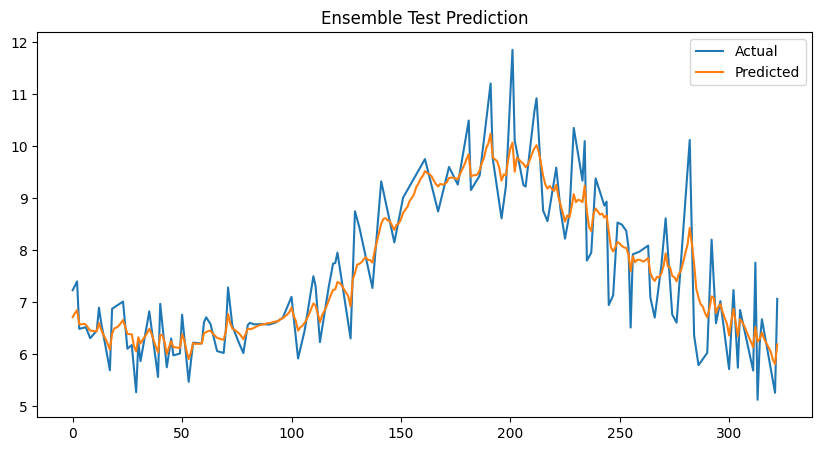

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_final, label="Actual")
plt.plot(ensemble_test_pred, label="Predicted")
plt.legend()
plt.title("Ensemble Test Prediction")
plt.show()

In [41]:
best_mape = float('inf')
best_weights = (0, 0)

for w_lstm in np.arange(0.1, 1.0, 0.1):
    w_xgb = 1 - w_lstm

    ensemble_pred = (w_lstm * lstm_test_pred) + (w_xgb * xgb_test_pred)

    mae, rmse, mape = evaluate(y_true, ensemble_pred)

    print(f"LSTM: {w_lstm:.1f}, XGB: {w_xgb:.1f} → MAPE: {mape:.2f}%")

    if mape < best_mape:
        best_mape = mape
        best_weights = (w_lstm, w_xgb)

print("\nBEST WEIGHTS:")
print(f"LSTM: {best_weights[0]:.2f}, XGB: {best_weights[1]:.2f}")
print(f"Best MAPE: {best_mape:.2f}%")

LSTM: 0.1, XGB: 0.9 → MAPE: 1.95%
LSTM: 0.2, XGB: 0.8 → MAPE: 2.40%
LSTM: 0.3, XGB: 0.7 → MAPE: 2.90%
LSTM: 0.4, XGB: 0.6 → MAPE: 3.41%
LSTM: 0.5, XGB: 0.5 → MAPE: 3.93%
LSTM: 0.6, XGB: 0.4 → MAPE: 4.45%
LSTM: 0.7, XGB: 0.3 → MAPE: 4.98%
LSTM: 0.8, XGB: 0.2 → MAPE: 5.52%
LSTM: 0.9, XGB: 0.1 → MAPE: 6.06%

BEST WEIGHTS:
LSTM: 0.10, XGB: 0.90
Best MAPE: 1.95%


In [42]:
w_lstm, w_xgb = best_weights

ensemble_pred = (w_lstm * lstm_test_pred) + (w_xgb * xgb_test_pred)

In [48]:
ens_test_mae, ens_test_rmse, ens_test_mape = evaluate(y_true, ensemble_pred)

print(" FINAL ENSEMBLE (OPTIMIZED WEIGHTS)\n")
print(f"Weights → LSTM: {w_lstm:.2f}, XGB: {w_xgb:.2f}\n")

print("TEST SET:")
print(f"MAE  : {ens_test_mae:.4f}")
print(f"RMSE : {ens_test_rmse:.4f}")
print(f"MAPE : {ens_test_mape:.2f}%")

 FINAL ENSEMBLE (OPTIMIZED WEIGHTS)

Weights → LSTM: 0.10, XGB: 0.90

TEST SET:
MAE  : 0.1478
RMSE : 0.2432
MAPE : 1.95%


In [52]:
print("\n MODEL COMPARISON\n")

print("LSTM:")
print(f"MAPE: {lstm_test_mape:.2f}%")

print("\nXGBoost:")
print(f"MAPE: {xgb_test_mape:.2f}%")

print("\nENSEMBLE (Optimized):")
print(f"MAPE: {ens_test_mape:.2f}%")


 MODEL COMPARISON

LSTM:
MAPE: 6.59%

XGBoost:
MAPE: 1.57%

ENSEMBLE (Optimized):
MAPE: 1.95%
